## Libraries and constants

In [226]:
# Source - https://stackoverflow.com/a/9031848
# Posted by astrofrog, modified by community. See post 'Timeline' for change history
# Retrieved 2026-04-27, License - CC BY-SA 4.0
import warnings
warnings.filterwarnings('ignore')


TMINUS = '2014-01-01' 
START = '2015-01-01'
END = '2024-12-31'

YEARLY_TRADING_DATES = 252 # n
MONTHLY_TRADING_DATES = YEARLY_TRADING_DATES / 12 # = 21 trading days/month
T_FACTOR = MONTHLY_TRADING_DATES / YEARLY_TRADING_DATES # (1+r/n)^{t_factor*n}

MONEYNESS = {'CC': 1.02, 'PP': 0.98}

## Yahoo Finance scraping and Feature engineering

In [ ]:
import yfinance as yf
import pandas as pd
tickers = ['^GSPC', '^VIX', '^TYX']
# Documentation: https://ranaroussi.github.io/yfinance/reference/api/yfinance.download.html#yfinance.download
df = yf.download(tickers, start=TMINUS, end=END, interval='1d',multi_level_index=True)
# Inspiration from https://www.kaggle.com/code/alessandrozanette/s-p500-analysis-using-yfinance-data
df = df.drop(columns=['High', 'Low', 'Open', 'Volume']) # Irrelevant columns
for ticker in tickers:
    if ticker != "^GSPC":
        df.loc[:, ('Close', ticker)] = df.loc[:, ('Close', ticker)] / 100 # From percent to decimal

df5 = pd.read_csv('VIX1Y.csv')
df5['Date'] = pd.to_datetime(df5['Date'], format='%m/%d/%Y')
df5 = df5.set_index('Date')
df = pd.concat([df, df5], axis=1, join='inner')
df = df.drop(columns=['High', 'Low', 'Open', 'Vol.', 'Change %']) # Irrelevant columns
df = df.rename(columns={'Price': ('Close', '^VIX1Y')})

# Source - https://stackoverflow.com/a/43896326
# Posted by MaxU - stand with Ukraine
# Retrieved 2026-04-27, License - CC BY-SA 3.0

newCols = {'Close_^GSPC': 'sp500', 'Close_^VIX': 'sigma', 'Close_^TYX': 'rf', 'Close_^VIX1Y': 'VIX1Y'} # rf = risk free rate
df.columns = df.columns.map('_'.join).to_series().map(newCols)
df['VIX1Y'] = df['VIX1Y'] / 100

df

# sp500.tail() # shows the last values
# sp500.describe() # count, max, min, std etc

[*********************100%***********************]  3 of 3 completed


,sp500,rf,sigma,VIX1Y
Date,,,,
2014-01-02,1831.979980,0.03919,0.1423,0.1843
2014-01-03,1831.369995,0.03930,0.1376,0.1844
2014-01-06,1826.770020,0.03898,0.1355,0.1829
2014-01-07,1837.880005,0.03881,0.1292,0.1791
2014-01-08,1837.489990,0.03903,0.1287,0.1796
...,...,...,...,...
2024-12-23,5974.069824,0.04784,0.1678,0.2124
2024-12-24,6040.040039,0.04765,0.1427,0.2080
2024-12-26,6037.589844,0.04762,0.1473,0.2074


## Black-Scholes

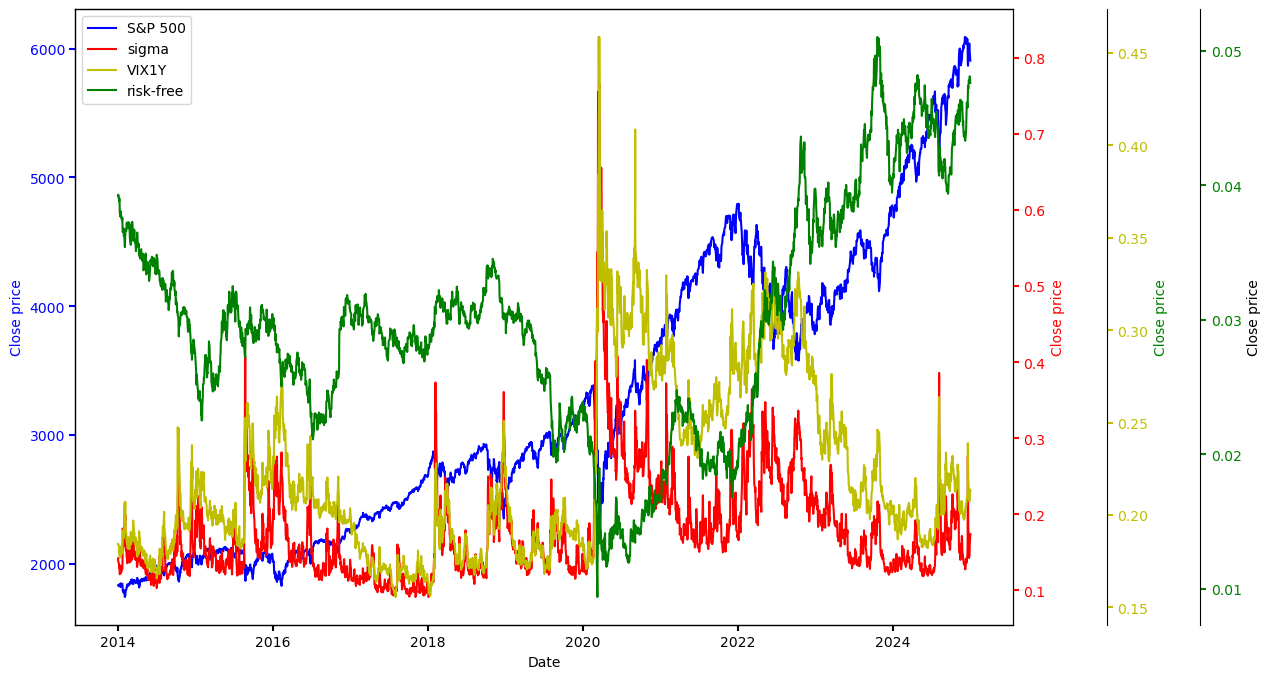

In [284]:
import matplotlib.pyplot as plt

# Source - https://stackoverflow.com/a/14770827
# Posted by Rutger Kassies, modified by community. See post 'Timeline' for change history
# Retrieved 2026-04-27, License - CC BY-SA 4.0
fig, ax = plt.subplots(figsize=(15, 8))

# Plot inspiration from: https://matplotlib.org/3.4.3/gallery/ticks_and_spines/multiple_yaxis_with_spines.html
fig.subplots_adjust(right=0.75)

twin1 = ax.twinx()
twin2 = ax.twinx()
twin3 = ax.twinx()
twin2.spines.right.set_position(("axes", 1.1))
twin3.spines.right.set_position(("axes", 1.2))

p1, = ax.plot(df['sp500'], "b-", label="S&P 500")
p2, = twin1.plot(df['sigma'], "r-", label="sigma")
p3, = twin2.plot(df['VIX1Y'], "y-", label="VIX1Y")
p4, = twin3.plot(df['rf'], "g-", label="risk-free")

ax.set_xlabel("Date")
ax.set_ylabel("Close price")
twin1.set_ylabel("Close price")
twin2.set_ylabel("Close price")
twin3.set_ylabel("Close price")

ax.yaxis.label.set_color(p1.get_color())
twin1.yaxis.label.set_color(p2.get_color())
twin2.yaxis.label.set_color(p3.get_color())
twin2.yaxis.label.set_color(p4.get_color())

tkw = dict(size=4, width=1.5)
ax.tick_params(axis='y', colors=p1.get_color(), **tkw)
twin1.tick_params(axis='y', colors=p2.get_color(), **tkw)
twin2.tick_params(axis='y', colors=p3.get_color(), **tkw)
twin3.tick_params(axis='y', colors=p4.get_color(), **tkw)
ax.tick_params(axis='x', **tkw)

ax.legend(handles=[p1, p2, p3, p4])

plt.show()

In [ ]:
# Taken from: https://theaiquant.medium.com/mastering-the-black-scholes-model-with-python-a-comprehensive-guide-to-option-pricing-11af712697b7
import numpy as np
import scipy.stats as si
from datetime import datetime

class BlackScholesModel:
    def __init__(self, S, K, T, r, sigma):
        self.S = S        # Underlying asset price
        self.K = K        # Option strike price
        self.T = T        # Time to expiration in years
        self.r = r        # Risk-free interest rate
        self.sigma = sigma  # Volatility of the underlying asset

    def d1(self):
        return (np.log(self.S / self.K) + (self.r + 0.5 * self.sigma ** 2) * self.T) / (self.sigma * np.sqrt(self.T))
    
    def d2(self):
        return self.d1() - self.sigma * np.sqrt(self.T)
    
    def call_option_price(self):
        return (self.S * si.norm.cdf(self.d1(), 0.0, 1.0) - self.K * np.exp(-self.r * self.T) * si.norm.cdf(self.d2(), 0.0, 1.0))
    
    def put_option_price(self):
        return (self.K * np.exp(-self.r * self.T) * si.norm.cdf(-self.d2(), 0.0, 1.0) - self.S * si.norm.cdf(-self.d1(), 0.0, 1.0))


def calculate_historical_volatility(stock_data, window=252):
    log_returns = np.log(stock_data / stock_data.shift(1))
    volatility = np.sqrt(window) * log_returns.std()
    return volatility

# Lambda functions + pandas apply: Source - https://stackoverflow.com/a/60125623
# Posted by Araldo van de Kraats
# Retrieved 2026-04-27, License - CC BY-SA 4.0

# df['Call (VIX vol)'] = df.apply(lambda x: BlackScholesModel(S = x.sp500, K = x.sp500*MONEYNESS['CC'], T = 1, r = x.rf, sigma = x.sigma).call_option_price(), axis=1)
# df['Put (VIX vol)'] = df.apply(lambda x: BlackScholesModel(S = x.sp500, K = x.sp500*MONEYNESS['PP'], T = 1, r = x.rf, sigma = x.sigma).put_option_price(), axis=1)

df['Call (VIX1y vol)'] = df.apply(lambda x: BlackScholesModel(S = x.sp500, K = x.sp500*MONEYNESS['CC'], T = 1, r = x.rf, sigma = x.VIX1Y).call_option_price(), axis=1)
df['Put (VIX1y vol)'] = df.apply(lambda x: BlackScholesModel(S = x.sp500, K = x.sp500*MONEYNESS['PP'], T = 1, r = x.rf, sigma = x.VIX1Y).put_option_price(), axis=1)

# df['Historical vol'] = df['sp500'].rolling(window=252, min_periods=252).apply(calculate_historical_volatility)
# df = df.dropna() # remove tminus after first run
# df['vol diff'] = df['sigma'] - df['Historical vol']
# df['vol diff2'] = df['sigma'] - df['VIX1Y']
# df

# Source - https://stackoverflow.com/a/28681097
# Posted by Adam Smith, modified by community. See post 'Timeline' for change history
# Retrieved 2026-04-24, License - CC BY-SA 3.0

import calendar

c = calendar.Calendar(firstweekday=calendar.SUNDAY)

df['Date'] = df.index
year = df['Date'].min().year
month = df['Date'].min().month

fridays = df[df['Date'] > '3000-04-23']

while(year <= df['Date'][len(df['Date'])-1].year):
    monthcal = c.monthdatescalendar(year,month)
    third_friday = [day for week in monthcal for day in week if \
                    day.weekday() == calendar.FRIDAY and \
                    day.month == month][2]
    fridays = pd.concat([fridays, df[df['Date'] == str(third_friday)]], ignore_index=True)
    if month == 12:
        month = 1
        year += 1
    else: month += 1

fridays

,sp500,rf,sigma,VIX1Y,Call (VIX vol),Put (VIX vol),Call (VIX1y vol),Put (VIX1y vol),Historical vol,vol diff,vol diff2,Date
0,2019.420044,0.02435,0.2095,0.2208,172.710139,124.501556,181.738666,133.165368,0.117851,0.091649,-0.0113,2015-01-16
1,2110.300049,0.02735,0.1430,0.2068,127.935472,74.918082,181.187825,125.207616,0.116163,0.026837,-0.0638,2015-02-20
2,2108.100098,0.02504,0.1302,0.2003,114.730633,66.762189,173.297103,121.990835,0.118352,0.011848,-0.0701,2015-03-20
3,2081.179932,0.02505,0.1389,0.2001,120.458352,72.559879,170.929129,120.266623,0.115806,0.023094,-0.0612,2015-04-17
4,2122.729980,0.02923,0.1238,0.1957,114.541857,59.087570,174.836849,115.389590,0.117529,0.006271,-0.0719,2015-05-15
...,...,...,...,...,...,...,...,...,...,...,...,...
113,5554.250000,0.04149,0.1480,0.2008,387.175876,178.851734,501.558403,284.856207,0.124972,0.023028,-0.0528,2024-08-16
114,5702.549805,0.04071,0.1615,0.2147,425.241332,212.645825,543.730824,323.437793,0.126595,0.034905,-0.0532,2024-09-20
115,5864.669922,0.04380,0.1803,0.2129,489.478589,251.787461,563.917400,321.482510,0.124043,0.056257,-0.0326,2024-10-18
116,5870.620117,0.04601,0.1614,0.2072,453.530646,207.691441,557.871826,304.469789,0.122720,0.038680,-0.0458,2024-11-15


In [311]:
# fridays = fridays.drop([0])
# fridays = fridays.set_index('Date')

def coveredCallProfit(st, k, p, s0):
    # min(St, K) + p − S0
    return min(st, k) + p - s0

def protectivePutProfit(st, k, p, s0):
    # St + max(K − St, 0) − p − S0
    return st + max(k-st,0) - p - s0

fridays['CC return'] = 1.0/12 * fridays.apply(lambda x: coveredCallProfit(
    st=x['sp500'], # price at maturity
    k=fridays.iloc[fridays.index.get_loc(x.name) - 12]['sp500'] * MONEYNESS['CC'] if fridays.index.get_loc(x.name) > 0 else x['sp500'] * MONEYNESS['CC'],
    p=fridays.iloc[fridays.index.get_loc(x.name) - 12]['Call (VIX1y vol)'], 
    s0=fridays.iloc[fridays.index.get_loc(x.name) - 12]['sp500'] if fridays.index.get_loc(x.name) > 0 else x['sp500']
) if fridays.index.get_loc(x.name) > 11 else 0, axis=1)

fridays['PP return'] = 1.0/12 * fridays.apply(lambda x: protectivePutProfit(
    st=x['sp500'], # price at maturity
    k=fridays.iloc[fridays.index.get_loc(x.name) - 12]['sp500'] * MONEYNESS['PP'] if fridays.index.get_loc(x.name) > 0 else x['sp500'] * MONEYNESS['PP'],
    p=fridays.iloc[fridays.index.get_loc(x.name) - 12]['Put (VIX1y vol)'], 
    s0=fridays.iloc[fridays.index.get_loc(x.name) - 12]['sp500'] if fridays.index.get_loc(x.name) > 0 else x['sp500']
) if fridays.index.get_loc(x.name) > 11 else 0, axis=1)

fridays['sp500 return'] = (fridays['sp500'].subtract(fridays['sp500'].shift(12))).div(fridays['sp500'].shift(12))

fridays.head(20)
# fridays


,sp500,rf,sigma,VIX1Y,Call (VIX vol),Put (VIX vol),Call (VIX1y vol),Put (VIX1y vol),Historical vol,vol diff,vol diff2,CC return,PP return,sp500 return
Date,,,,,,,,,,,,,,
2015-01-16,2019.420044,0.02435,0.2095,0.2208,172.710139,124.501556,181.738666,133.165368,0.117851,0.091649,-0.0113,0.000000,0.000000,NaN
2015-02-20,2110.300049,0.02735,0.1430,0.2068,127.935472,74.918082,181.187825,125.207616,0.116163,0.026837,-0.0638,0.000000,0.000000,NaN
2015-03-20,2108.100098,0.02504,0.1302,0.2003,114.730633,66.762189,173.297103,121.990835,0.118352,0.011848,-0.0701,0.000000,0.000000,NaN
2015-04-17,2081.179932,0.02505,0.1389,0.2001,120.458352,72.559879,170.929129,120.266623,0.115806,0.023094,-0.0612,0.000000,0.000000,NaN
2015-05-15,2122.729980,0.02923,0.1238,0.1957,114.541857,59.087570,174.836849,115.389590,0.117529,0.006271,-0.0719,0.000000,0.000000,NaN
2015-06-19,2109.989990,0.03056,0.1396,0.1962,128.420935,69.765423,175.541302,113.925066,0.119120,0.020480,-0.0566,0.000000,0.000000,NaN
2015-07-17,2126.639893,0.03083,0.1195,0.1837,112.858126,54.763157,166.719240,104.659976,0.122267,-0.002767,-0.0642,0.000000,0.000000,NaN
2015-08-21,1970.890015,0.02747,0.2803,0.2168,226.441774,171.757348,177.113090,124.278315,0.127958,0.152342,0.0635,0.000000,0.000000,NaN
2015-09-18,1958.030029,0.02929,0.2228,0.2372,182.259336,126.357390,193.371254,137.008798,0.151468,0.071332,-0.0144,0.000000,0.000000,NaN
